# Dataset

### Dataset 확인 

In [1]:
import pandas as pd

In [2]:
csv_file = "./data/training/nutrition.csv"

df = pd.read_csv(csv_file)

print(f"(전체 데이터 수, 전체 컬럼 수): {df.shape}")
df.head(2)

(전체 데이터 수, 전체 컬럼 수): (198, 6)


,user_input,reference,reference_video_url,persona_name,query_style,query_length
0,체중에 대한 잘못된 정보는 무엇인가요?,"'하루 1,000ml만 넘지 않으면 괜찮다'는 이야기는 잘못된 정보입니다. 실제로 ...",https://www.youtube.com/watch?v=08B0VqzITbU,a pediatric nutrition expert,MISSPELLED,SHORT
1,수유에 대해 아기가 스스로 먹게 하려면 어떻게 해야 하나요?,아기를 먹일 때는 시간을 엄격히 정해 억지로 먹이거나 먹는 양을 지나치게 재지 말고...,https://www.youtube.com/watch?v=QLlu_Zmr9wQ,a pediatrician,MISSPELLED,MEDIUM


### 허깅페이스 데이터셋으로 변환 

In [3]:
from datasets import load_dataset

In [4]:
csv_dataset = load_dataset("csv", data_files=csv_file)

In [5]:
print("CSV 데이터셋:")
print(csv_dataset)

CSV 데이터셋:
DatasetDict({
    train: Dataset({
        features: ['user_input', 'reference', 'reference_video_url', 'persona_name', 'query_style', 'query_length'],
        num_rows: 198
    })
})


In [6]:
print("\n첫 번째 샘플:")
print(csv_dataset["train"][0])


첫 번째 샘플:
{'user_input': '체중에 대한 잘못된 정보는 무엇인가요?', 'reference': "'하루 1,000ml만 넘지 않으면 괜찮다'는 이야기는 잘못된 정보입니다. 실제로 하루 1,000ml 정도 먹는 아기는 드물고, 이런 아기들 중에는 체중 과다나 이유식 문제 등 다른 문제가 있는 경우가 많습니다.", 'reference_video_url': 'https://www.youtube.com/watch?v=08B0VqzITbU', 'persona_name': 'a pediatric nutrition expert', 'query_style': 'MISSPELLED', 'query_length': 'SHORT'}


# Upload Dataset to Huggingface hub

### [환경변수 등록](https://huggingface.co/settings/tokens)

In [7]:
from dotenv import load_dotenv 

# .env 파일에 있는 데이터를 환경변수에 등록해주는 함수 
load_dotenv()

True

### 업로드 
```python
csv_dataset.push_to_hub("허깅페이스 아이디/데이터셋이름")
```

In [8]:
csv_dataset.push_to_hub("good593/nutrition-dataset")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/good593/nutrition-dataset/commit/9d4e14040afe7b5b23edd3eefc5925f5e772d6a5', commit_message='Upload dataset', commit_description='', oid='9d4e14040afe7b5b23edd3eefc5925f5e772d6a5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/good593/nutrition-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='good593/nutrition-dataset'), pr_revision=None, pr_num=None)

### [결과 확인](https://huggingface.co/datasets/good593/nutrition-dataset)

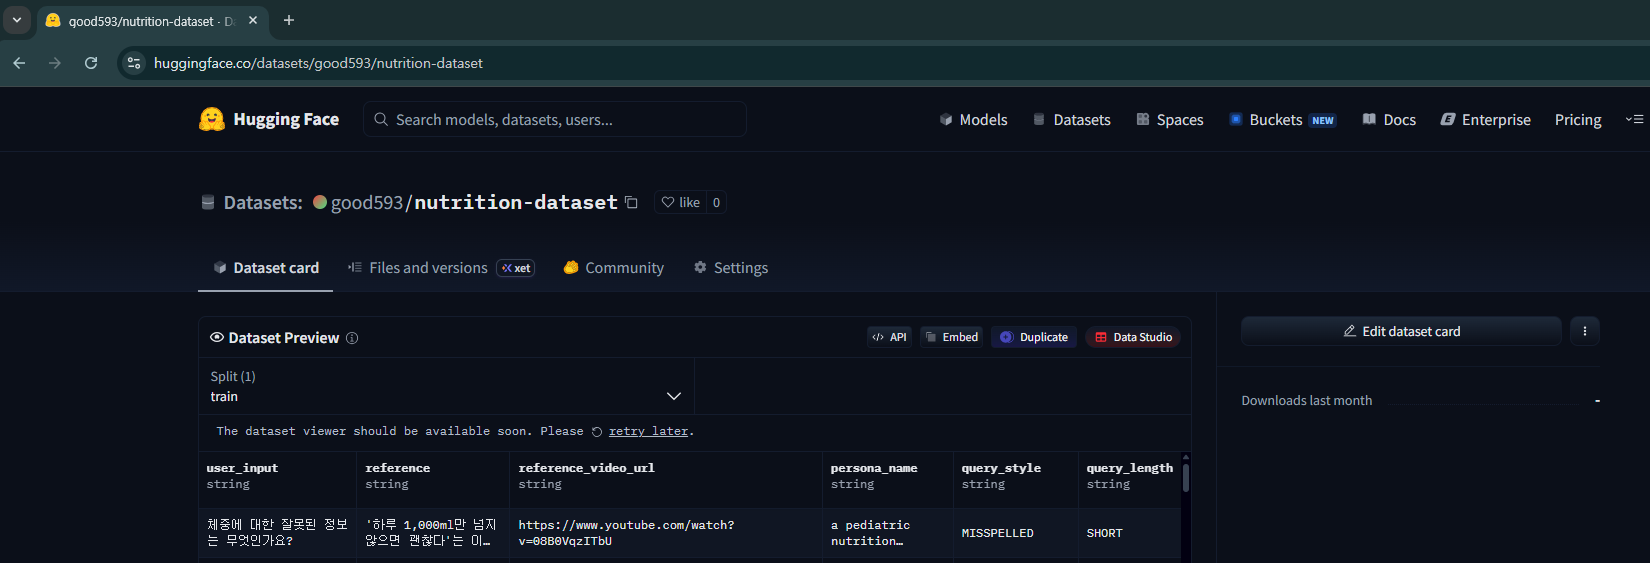